# Import the Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import re 
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# Problem Statement 
#### In this data we have one independent variable 'Temperature' and one dependent variable 'Revenue' .You have to build the DecisionTreeRegressor to study the relationship b/w the 2 variables and then predict the revenue for the ice cream shop based on the particular day .

# Import the Dataset

In [2]:
df = pd.read_csv('IceCreamData.csv')

In [3]:
df.head()

,Temperature,Revenue
0,24.566884,534.799028
1,26.005191,625.190122
2,27.790554,660.632289
3,20.595335,487.706960
4,11.503498,316.240194


In [4]:
df.tail()

,Temperature,Revenue
495,22.274899,524.746364
496,32.893092,755.818399
497,12.588157,306.090719
498,22.362402,566.217304
499,28.957736,655.660388


In [5]:
df.describe()

,Temperature,Revenue
count,500.000000,500.000000
mean,22.232225,521.570777
std,8.096388,175.404751
min,0.000000,10.000000
25%,17.122258,405.558681
50%,22.392791,529.368565
75%,27.740674,642.257922
max,45.000000,1000.000000


In [6]:
df.isnull().sum()

Temperature    0
Revenue        0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


Text(0.5, 1.0, 'Temp v/s Revenue')

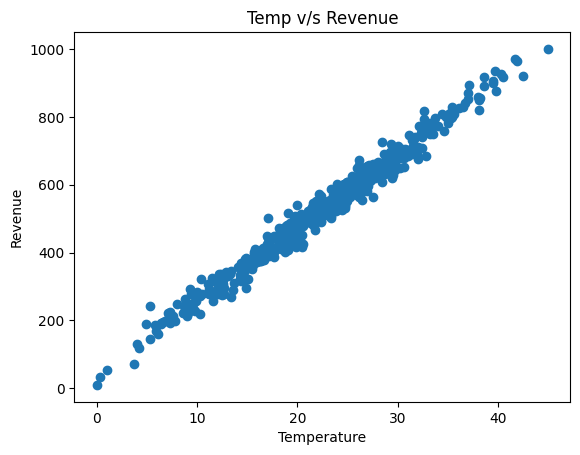

In [8]:
# Relationship b/w temp and revenue 
plt.scatter(df.Temperature,df.Revenue)
plt.xlabel('Temperature')
plt.ylabel('Revenue')
plt.title('Temp v/s Revenue')

<Axes: >

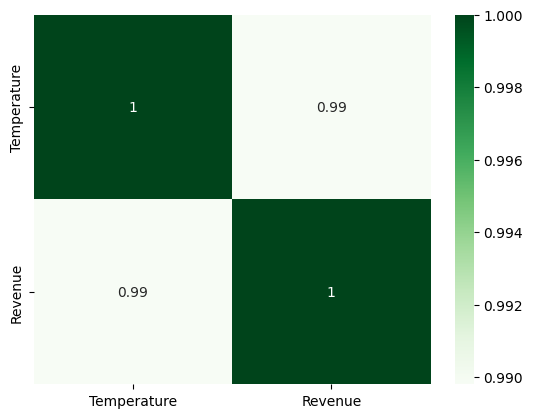

In [9]:
sns.heatmap(df.corr(),annot = True, cmap='Greens')

<Axes: >

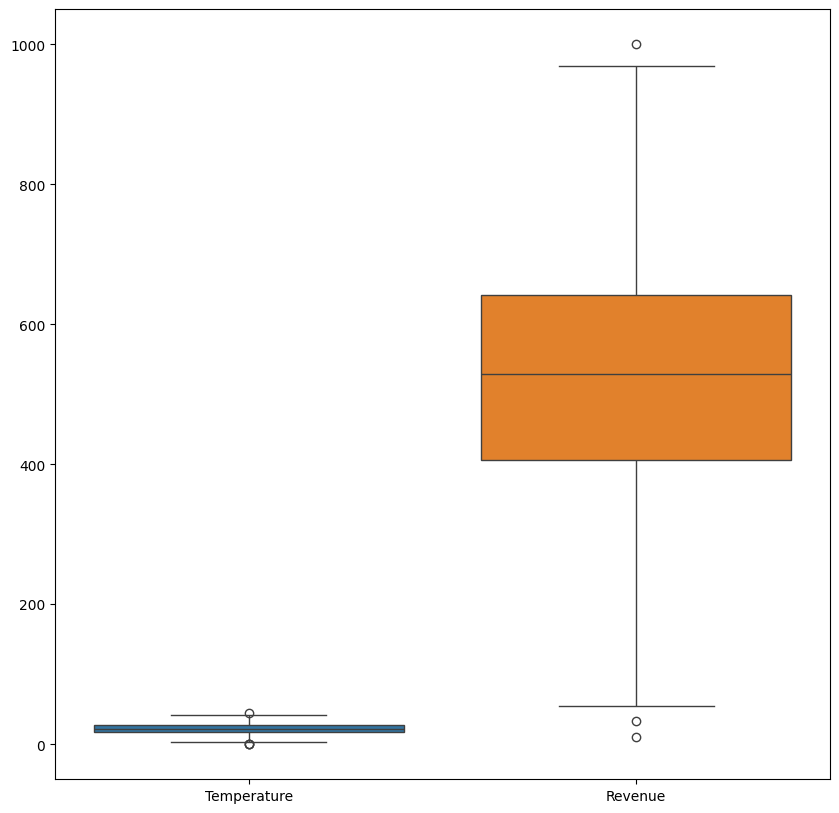

In [10]:
# Outliers
plt.figure (figsize= (10,10))
sns.boxplot(df)

# Machine Learning

## Spliting of Data - Training and Testing set

In [11]:
X = np.array(df.Temperature.values)
Y = np.array(df.Revenue.values)

In [12]:
x_train , x_test , y_train , y_test = train_test_split(X,Y ,test_size=0.2,random_state=22)

In [13]:
len(x_test)

100

In [14]:
len(x_train)

400

# Model Selection

In [15]:
regressor = DecisionTreeRegressor()

# Train the Model 

In [16]:
regressor.fit(x_train.reshape(-1, 1),y_train.reshape(-1, 1))

DecisionTreeRegressor()

# Test the Model 

In [17]:
y_pred= regressor.predict(x_test.reshape(-1, 1))

In [18]:
y_pred

array([697.8339862, 564.3105317, 696.7166402, 594.1103517, 333.3342585,
       430.3439033, 683.5447809, 520.4703098, 279.866148 , 321.8482734,
       532.05402  , 643.9443266, 583.0844489, 351.2888691, 353.3256334,
       493.1154676, 443.1136034, 469.9090332, 682.8085663, 682.8085663,
       552.8193512, 781.9837945, 627.6508336, 612.8037704, 523.1245467,
       546.6938576, 809.3525195, 706.7246037, 604.6266727, 550.055216 ,
       534.3645388, 450.4732071, 242.2362083, 425.0120182, 321.8482734,
       571.4342569, 653.9867356, 216.183462 , 497.7523178, 473.5681122,
       563.3816326, 818.135393 , 918.3912316, 969.2916296, 537.6648006,
       276.787086 , 321.7500343, 648.5546445, 471.7015569, 651.8615363,
       851.3430963, 308.8945179, 827.6848313, 809.6720534, 534.3645388,
       535.7089203, 678.7513876, 501.7329901, 639.5380115, 639.5380115,
       413.9140669, 819.1175879, 278.4182651, 334.4337199, 850.2469822,
       212.4835594, 607.8391938, 542.8391063, 521.6728037, 609.4

In [19]:
y_test

array([746.9463889, 550.7014036, 706.3649044, 538.31289  , 319.4029032,
       402.3984607, 696.6401775, 526.7008607, 303.7343815, 284.7727889,
       543.9850584, 660.6322888, 596.2366902, 361.1191443, 356.0980075,
       566.2173038, 427.1383693, 427.2113597, 662.5589903, 641.0253891,
       539.6880057, 798.0597179, 658.5937316, 623.2487008, 584.399945 ,
       524.2361154, 756.9625616, 759.3774317, 581.2620157, 540.798122 ,
       542.6080704, 517.5340283, 246.7871609, 487.7069603, 257.078777 ,
       587.2212461, 633.5040087, 223.4350161, 493.2266364, 453.7856066,
       674.1506442, 793.079011 , 926.0671533, 965.4930396, 545.9039291,
       295.3396989, 278.3098441, 627.2912952, 416.8486183, 702.9017171,
       870.7659159, 289.5409341, 841.1714271, 809.7777259, 570.9909316,
       507.900282 , 697.1474728, 441.5087331, 655.4339792, 625.8046425,
       440.6778286, 857.5266413, 297.0254137, 322.592741 , 856.3033039,
       198.1215634, 651.486741 , 539.5277397, 496.0119175, 574.4

In [20]:
regressor.predict(np.array([18]).reshape(-1, 1))

array([441.0029443])

# Comparing y_test and y_pred

In [21]:
comp = pd.DataFrame({'Actual_Val':y_test.reshape(-1),'predicted_Val':y_pred.reshape(-1)})

In [22]:
comp

,Actual_Val,predicted_Val
0,746.946389,697.833986
1,550.701404,564.310532
2,706.364904,696.716640
3,538.312890,594.110352
4,319.402903,333.334258
...,...,...
95,402.455320,396.935648
96,315.646581,367.940744
97,726.233771,607.839194
98,508.720471,491.230603


Text(0.5, 1.0, 'y_test v/s y_pred')

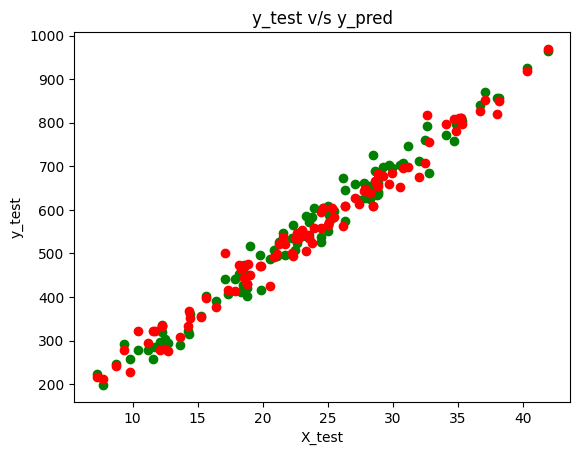

In [23]:
plt.scatter(x_test , y_test,color ='green')
plt.scatter(x_test , y_pred,color ='red')
plt.xlabel('X_test')
plt.ylabel('y_test')
plt.title('y_test v/s y_pred')

In [41]:
print(x_test.shape)
print(y_test.shape)
print(y_pred.shape)

(100,)
(100,)
(100,)


<Axes: >

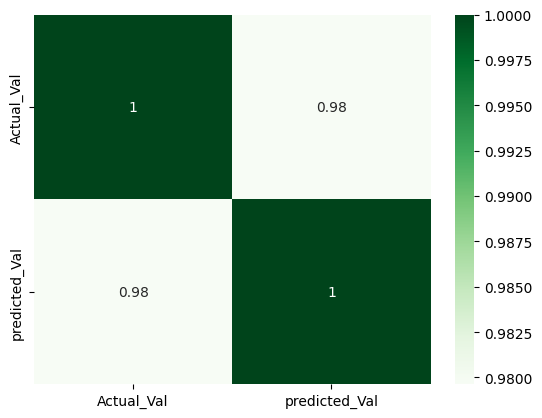

In [24]:
# correlation b/w ytest and ypred along with value 
sns.heatmap(comp.corr(),annot=True,cmap ='Greens')

<Axes: >

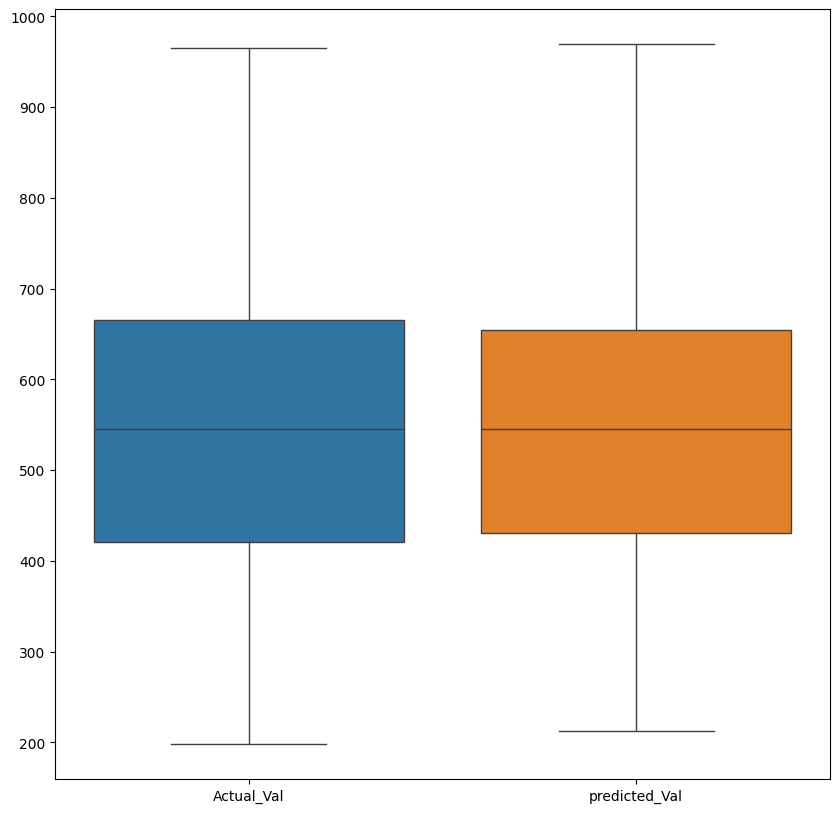

In [25]:
# Outliers
plt.figure (figsize= (10,10))
sns.boxplot(comp)

# Performance

In [26]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [27]:
r2_score(y_pred,y_test)

0.9559793702859609

In [28]:
mean_squared_error(y_pred,y_test)

1268.6915480256416

In [29]:
mean_absolute_error(y_pred,y_test)

27.52970599499999

 # Factors that tells that we have choosen a perfect model
* Compare a model with other model
  

In [30]:
# Feature scaling 
from sklearn.preprocessing import StandardScaler

In [31]:
X = np.array(df.Temperature.values)
Y = np.array(df.Revenue.values)
x_train , x_test , y_train , y_test = train_test_split(X,Y ,test_size=0.2,random_state=22)

In [32]:
x_scaler = StandardScaler()
y_scaler = StandardScaler()
scaled_x_test = x_scaler.fit_transform(x_test.reshape(-1,1))
scaled_x_train = x_scaler.fit_transform(x_train.reshape(-1,1))
scaled_y_train = y_scaler.fit_transform(y_train.reshape(-1,1))

In [33]:
regressor.fit(scaled_x_train,scaled_y_train)

DecisionTreeRegressor()

In [34]:
scaled_y_pred = regressor.predict(scaled_x_test)

In [35]:
actual_y_pred = y_scaler.inverse_transform(scaled_y_pred.reshape(-1,1))

In [36]:
r2_score(actual_y_pred , y_test)

0.9142924727351485

In [37]:
y_test

array([746.9463889, 550.7014036, 706.3649044, 538.31289  , 319.4029032,
       402.3984607, 696.6401775, 526.7008607, 303.7343815, 284.7727889,
       543.9850584, 660.6322888, 596.2366902, 361.1191443, 356.0980075,
       566.2173038, 427.1383693, 427.2113597, 662.5589903, 641.0253891,
       539.6880057, 798.0597179, 658.5937316, 623.2487008, 584.399945 ,
       524.2361154, 756.9625616, 759.3774317, 581.2620157, 540.798122 ,
       542.6080704, 517.5340283, 246.7871609, 487.7069603, 257.078777 ,
       587.2212461, 633.5040087, 223.4350161, 493.2266364, 453.7856066,
       674.1506442, 793.079011 , 926.0671533, 965.4930396, 545.9039291,
       295.3396989, 278.3098441, 627.2912952, 416.8486183, 702.9017171,
       870.7659159, 289.5409341, 841.1714271, 809.7777259, 570.9909316,
       507.900282 , 697.1474728, 441.5087331, 655.4339792, 625.8046425,
       440.6778286, 857.5266413, 297.0254137, 322.592741 , 856.3033039,
       198.1215634, 651.486741 , 539.5277397, 496.0119175, 574.4

In [38]:
comp =pd.DataFrame({"Actual Y": y_test,"Predicted Y": y_pred})

In [39]:
comp

,Actual Y,Predicted Y
0,746.946389,697.833986
1,550.701404,564.310532
2,706.364904,696.716640
3,538.312890,594.110352
4,319.402903,333.334258
...,...,...
95,402.455320,396.935648
96,315.646581,367.940744
97,726.233771,607.839194
98,508.720471,491.230603


In [40]:
x_new = np.array([[28]])
x_new_scaled = x_scaler.transform(x_new)
y_new_scaled = regressor.predict(x_new_scaled)
y_new = y_scaler.inverse_transform(y_new_scaled.reshape(-1, 1))
print("Predicted Revenue for 25°C:", y_new)


Predicted Revenue for 25°C: [[628.4532107]]
